# Black Scholes Function

The core Idea of this model is to price an option through Black-Scholes' formula, then Solve for its implied volatility, and plot that. Later to be expanded on to a surface builder for Implied volatility.

The Core pricing formula is as follows:

$$C = SN(d_1) - Ke^{-rT}N(d_2)$$

Where:

S = current stock price

K = Strike price

T = time to maturity

r = risk-free interest rate

N(d) = probability (through a normal distribution)


We assume that the stock price is assumed to follow a log-normal distribution. Which means:

- $\ln(S_T)$  is normally distributed, not the price itself.

So everything we do including computing d1 and d2 is about stnadardizing this distribution so we can compute probabilities accurately.

Below, we computed the following:

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

and

$$d_2 = d_1 - \sigma\sqrt{T}$$

Which are both intermediate variables we use to standardize and end up getting a Call price. Now ofcourse our end goal is to find an implied volatility and plot it, however we must first at any one point *assume* a volatility $\sigma$

We'll afterward compute an implied volatility using a binary search, since we know option price increases with volatility, if we have a low $\sigma$ we have a low price and vice versa, This is a monotonic function which allows for a binary search.

In simple terms, we just want to solve the following question, for which no algebraic definite solution exists and for which we *must* use numerical methods:

$$\text{Market price} = f(\sigma)$$

In the code we define a possible volatility range(from 0.1% to 200%), and we estimate a middle in between those by taking their average and plugging that as our $\sigma$ in the Call price formula.

Now what we do is a conditional where if the price calculated from this is higher than the market price (which we input into our implied volatility solver function), then the guess for volatility is too high, if the price calculated by our model is too low, then the volatility guess is too low, so we kind of are finding a root for this.

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def implied_volatility(S, K, T, r, market_price):
    low = 0.001
    high = 3.0

    for _ in range(100):
        mid = (low + high) / 2
        price = black_scholes_call(S, K, T, r, mid)

        if price > market_price:
            high = mid
        else:
            low = mid

    return (low + high) / 2


# Creating our Data
As much as I'd love to use real data, this would shift away from the focus of this mini project, initially it was to show that it is possible to invert Black-Scholes to recover volatility.

When we input real data it becomes more like a trading system or a data pipeline more than it is a mathematical experiment.

So we will be using synthetic data and perhaps provide an example using real data later on. This works best becuase we already know our true volatility (becuase we assume it) So we're purely testing if we can backtrack it and retrieve it from our formula.

What we do now is define our True parameters, those being the following:

- $S$ = Stock price

- $r$ = interest rate

- $\sigma_{\text{true}}$ = real volatility

mathematically we will pull this:

$$ C_{\text{market}} = f(S, K, T, r, \sigma_{\text{true}})$$

We also have to account for the fact that volatility is most definitely not always a constant variable, if we say it was constant then we'll end up with a flat unflattering surface plot in the end. So what we do is we introduce maturity dependent volatility term to reflect increasing uncertainty as time passes. That would look something like:

$$\sigma_{\text{true}} = 0.2 + 0.12\ln{\frac{K}{S}} + 0.15\ln{\frac{K}{S}} + 0.10\sqrt{T} $$

This helps us properly combine two things, that being the log-moneyness effect on the volatility, and the Time effect, where a longer horizon means more unknown unknowns and more uncertainty.

Further explanation:

- **Moneyness**: $\ln{\frac{K}{S}}$
- **Time to maturity**: $T$

the surface also inclues:

- **smile** (curvature)
- **skew** (asymmetry between OTM calls and puts)
- **term structure** (dependence on time to maturity)

So this produces a non-flat, curved surface similar to what would be observed in a real market condition.

In [61]:
S = 100
r = 0.03

strikes = np.linspace(60, 140, 60)
maturities = np.linspace(0.05, 2.0, 60)

K_grid, T_grid = np.meshgrid(strikes, maturities)

moneyness = np.log(K_grid / S)

true_vol_surface = (
    0.20
    + 0.80 * moneyness**2
    - 0.35 * moneyness
    + 0.25 * np.exp(-2.0 * T_grid)
    + 0.15 * moneyness**2 * T_grid
)

Above, we created a *set* of strikes $K$, and maturities $T$. and then we deine a function over a 2D space, which means we're sampling a Surface and not just a single value.

Mathematically, we are evaluating the following:

$$C(K, T) = f(S, K, T, r, \sigma_{\text{true}})$$

so we're taking inputs of strike prices and maturities, and outputting an option price, volatility is *hidden* inside that price.

We'll also add some noise in order to simulate real market imperfections through Gaussian distribution to simlate market microstructure effects and pricing imperfections which are to be expected

In [62]:
market_prices = black_scholes_call(S, K_grid, T_grid, r, true_vol_surface)

# Implied Volatlity Recovery

Now we have to assume that we have no idea what $\sigma$ is. So we're solving the following:

$$C_{\text{market}} = f(\sigma)$$

for each (K, T) above.

What we do is we get an IV surface which is a matrix of its rows being the strikes and columns being the maturities, with the actual values being the implied volatility. So we reconstruct a function:

$$ \sigma = g(K, T)$$

which is the volatility surface (notice how it takes in K AND T, so that means its a surface)

So we iterate over every option point in the grid, take the known market price from our model, solve the formula, and recover $\sigma$ using our implied volatility solver defined above.

This step mathematically is simply just the numerical inversion of a nonlinear function. since there is no algebraic solution we approximate $\sigma$ iteratively step by step.

and finally we eventually have this surface:

$$\sigma(K, T) = g(K,T)$$

In [63]:
iv_surface = np.zeros_like(K_grid)

for j in range(len(maturities)):
    for i in range(len(strikes)):
        iv_surface[j, i] = implied_volatility(
            S,
            K_grid[j, i],
            T_grid[j, i],
            r,
            market_prices[j, i]
        )

print("IV min:", iv_surface.min())
print("IV max:", iv_surface.max())

IV min: 0.17674499632255886
IV max: 0.8157096482780846


# Visualizing everything

now that we've retraced our implied volatility on a surface, we have to plot it to visualize everything we've done.

We'll use the following:

our x-axis will be the strikes K

our y-axis will be the maturities T

and our z-axis will be our implied volatility that we solved.

We are basically visualizing a 3D scalar field.

We know that every $(K, T)$ maps to some $\sigma$ value, so the gried ensures our alignemnt.

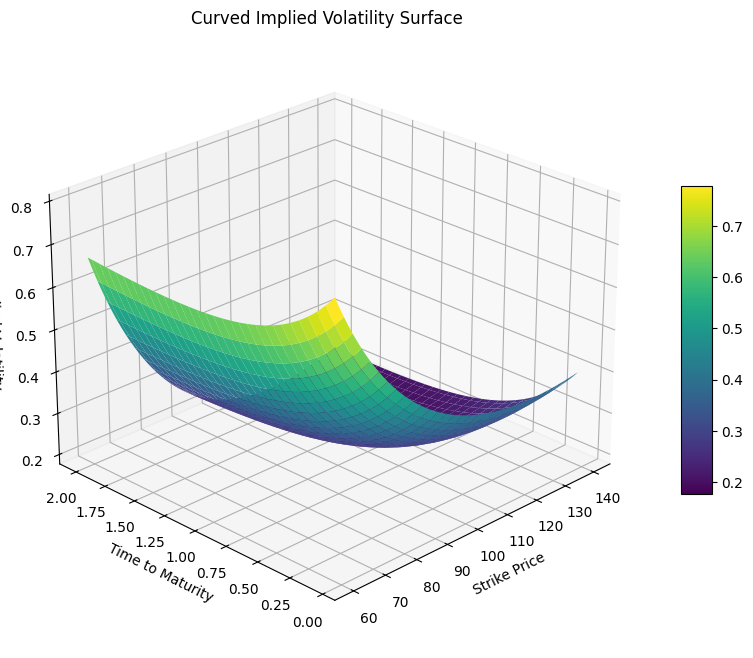

In [64]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    K_grid,
    T_grid,
    iv_surface,
    cmap="viridis",
    edgecolor="none"
)

ax.set_xlabel("Strike Price")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Implied Volatility")
ax.set_title("Curved Implied Volatility Surface")

ax.set_zlim(iv_surface.min(), iv_surface.max())
ax.view_init(elev=25, azim=-135)

fig.colorbar(surf, shrink=0.5, aspect=10)

plt.show()